# 📊 Projet 2 — Analyse des performances des employés
## HR Analytics Dataset (IBM)

**Objectif** : Analyser la répartition des performances des employés,  
comprendre les écarts entre départements et identifier les outliers.

**Dataset** : IBM HR Analytics (1 470 employés, 35 variables)  
**Outil** : Python (pandas, matplotlib, seaborn)  
**Auteur** : barde44  
**Date** : Mai 2026

In [2]:
# ============================================================
# SECTION 1 — IMPORTATION DES BIBLIOTHÈQUES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration de l'affichage
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Bibliothèques importées avec succès !")
print(f"   pandas    : {pd.__version__}")
print(f"   numpy     : {np.__version__}")
print(f"   seaborn   : {sns.__version__}")

✅ Bibliothèques importées avec succès !
   pandas    : 2.2.3
   numpy     : 2.2.0
   seaborn   : 0.13.2


In [3]:
# ============================================================
# SECTION 2 — CHARGEMENT ET EXPLORATION INITIALE
# ============================================================

# Chargement du dataset
df = pd.read_csv('../../dataset/hr_analytics.csv')

print(f"✅ Dataset chargé avec succès !")
print(f"   Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")

✅ Dataset chargé avec succès !
   Dimensions : 1470 lignes × 35 colonnes


In [4]:
# Aperçu des 5 premières lignes
print("=== APERÇU DES DONNÉES ===")
df.head()

=== APERÇU DES DONNÉES ===


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
# Informations sur les types de colonnes
print("=== INFORMATIONS GÉNÉRALES ===")
df.info()

=== INFORMATIONS GÉNÉRALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64

In [6]:
# Statistiques descriptives pour toutes les colonnes numériques
print("=== STATISTIQUES DESCRIPTIVES ===")
df.describe().round(2)

=== STATISTIQUES DESCRIPTIVES ===


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.00,1024.87,2.72,65.89,2.73,2.06,2.73,6502.93,14313.10,2.69,15.21,3.15,2.71,80.00,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.00,602.02,1.09,20.33,0.71,1.11,1.10,4707.96,7117.79,2.50,3.66,0.36,1.08,0.00,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,11.00,3.00,1.00,80.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.00,491.25,2.00,48.00,2.00,1.00,2.00,2911.00,8047.00,1.00,12.00,3.00,2.00,80.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.00,1020.50,3.00,66.00,3.00,2.00,3.00,4919.00,14235.50,2.00,14.00,3.00,3.00,80.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.00,1555.75,4.00,83.75,3.00,3.00,4.00,8379.00,20461.50,4.00,18.00,3.00,4.00,80.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.00,2068.00,4.00,100.00,4.00,5.00,4.00,19999.00,26999.00,9.00,25.00,4.00,4.00,80.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


## 🧹 Section 3 — Nettoyage et validation des données

Avant toute analyse, on vérifie :
- Les valeurs manquantes
- Les doublons
- Les colonnes inutiles
- Les types de données

In [7]:
# ============================================================
# SECTION 3 — NETTOYAGE ET VALIDATION
# ============================================================

# 3.1 Valeurs manquantes
print("=== VALEURS MANQUANTES ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
})

# Afficher uniquement les colonnes avec des valeurs manquantes
missing_filtered = missing_df[missing_df['Valeurs manquantes'] > 0]

if len(missing_filtered) == 0:
    print("✅ Aucune valeur manquante détectée !")
else:
    print(missing_filtered)

=== VALEURS MANQUANTES ===
✅ Aucune valeur manquante détectée !


In [8]:
# 3.2 Doublons
doublons = df.duplicated().sum()
print(f"=== DOUBLONS ===")
print(f"Nombre de lignes dupliquées : {doublons}")

if doublons == 0:
    print("✅ Aucun doublon détecté !")
else:
    print(f"⚠️ {doublons} doublons trouvés — suppression...")
    df = df.drop_duplicates()
    print(f"✅ Doublons supprimés. Nouveau shape : {df.shape}")

=== DOUBLONS ===
Nombre de lignes dupliquées : 0
✅ Aucun doublon détecté !


In [9]:
# 3.3 Colonnes inutiles
# Ce dataset IBM contient 2 colonnes constantes (toujours la même valeur)
# qui n'apportent aucune information analytique

print("=== COLONNES CONSTANTES ===")
colonnes_constantes = [col for col in df.columns if df[col].nunique() == 1]
print(f"Colonnes avec une seule valeur unique : {colonnes_constantes}")

# Suppression
df = df.drop(columns=colonnes_constantes)
print(f"\n✅ Colonnes supprimées : {colonnes_constantes}")
print(f"   Nouveau shape : {df.shape}")

=== COLONNES CONSTANTES ===
Colonnes avec une seule valeur unique : ['EmployeeCount', 'Over18', 'StandardHours']

✅ Colonnes supprimées : ['EmployeeCount', 'Over18', 'StandardHours']
   Nouveau shape : (1470, 32)


In [10]:
# 3.4 Résumé des colonnes restantes
print("=== COLONNES DISPONIBLES POUR L'ANALYSE ===\n")

# Colonnes numériques
cols_num = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"📊 Colonnes NUMÉRIQUES ({len(cols_num)}) :")
print(cols_num)

print()

# Colonnes catégorielles
cols_cat = df.select_dtypes(include=['object']).columns.tolist()
print(f"📝 Colonnes CATÉGORIELLES ({len(cols_cat)}) :")
print(cols_cat)

=== COLONNES DISPONIBLES POUR L'ANALYSE ===

📊 Colonnes NUMÉRIQUES (24) :
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

📝 Colonnes CATÉGORIELLES (8) :
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


## 📊 Section 4 — Statistiques descriptives

On va analyser les variables clés :
- `MonthlyIncome` : salaire mensuel
- `Age` : âge des employés
- `YearsAtCompany` : ancienneté
- `PerformanceRating` : note de performance (1-4)
- `JobSatisfaction` : satisfaction au travail (1-4)
- `WorkLifeBalance` : équilibre vie pro/perso (1-4)

In [11]:
# ============================================================
# SECTION 4 — STATISTIQUES DESCRIPTIVES
# ============================================================

# Variables clés à analyser
variables_cles = [
    'Age',
    'MonthlyIncome',
    'YearsAtCompany',
    'PerformanceRating',
    'JobSatisfaction',
    'WorkLifeBalance',
    'TotalWorkingYears',
    'DistanceFromHome'
]

# Statistiques complètes
stats = df[variables_cles].agg([
    'mean', 'median', 'std', 'min', 'max',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
]).round(2)

stats.index = ['Moyenne', 'Médiane', 'Écart-type', 'Min', 'Max', 'Q1 (25%)', 'Q3 (75%)']
print("=== STATISTIQUES DESCRIPTIVES DES VARIABLES CLÉS ===\n")
print(stats.to_string())

=== STATISTIQUES DESCRIPTIVES DES VARIABLES CLÉS ===

             Age  MonthlyIncome  YearsAtCompany  PerformanceRating  JobSatisfaction  WorkLifeBalance  TotalWorkingYears  DistanceFromHome
Moyenne    36.92        6502.93            7.01               3.15             2.73             2.76              11.28              9.19
Médiane    36.00        4919.00            5.00               3.00             3.00             3.00              10.00              7.00
Écart-type  9.14        4707.96            6.13               0.36             1.10             0.71               7.78              8.11
Min        18.00        1009.00            0.00               3.00             1.00             1.00               0.00              1.00
Max        60.00       19999.00           40.00               4.00             4.00             4.00              40.00             29.00
Q1 (25%)   30.00        2911.00            3.00               3.00             2.00             2.00               6.0

In [12]:
# Statistiques par département
print("=== SALAIRE MENSUEL PAR DÉPARTEMENT ===\n")

dept_stats = df.groupby('Department')['MonthlyIncome'].agg([
    ('Effectif', 'count'),
    ('Salaire moyen ($)', 'mean'),
    ('Salaire médian ($)', 'median'),
    ('Écart-type', 'std'),
    ('Min ($)', 'min'),
    ('Max ($)', 'max')
]).round(0)

print(dept_stats.to_string())

=== SALAIRE MENSUEL PAR DÉPARTEMENT ===

                        Effectif  Salaire moyen ($)  Salaire médian ($)  Écart-type  Min ($)  Max ($)
Department                                                                                           
Human Resources               63            6655.00             3886.00     5789.00     1555    19717
Research & Development       961            6281.00             4374.00     4896.00     1009    19999
Sales                        446            6959.00             5754.00     4059.00     1052    19847


In [14]:
# Distribution des notes de performance
print("=== DISTRIBUTION DES PERFORMANCES ===\n")

# Version corrigée : on laisse pandas détecter les valeurs présentes
perf_df = df['PerformanceRating'].value_counts().sort_index().reset_index()
perf_df.columns = ['Note de performance', 'Nombre']
perf_df['Pourcentage (%)'] = (perf_df['Nombre'] / len(df) * 100).round(1)

# Ajouter le libellé correspondant
labels = {1: 'Low', 2: 'Good', 3: 'Excellent', 4: 'Outstanding'}
perf_df['Libellé'] = perf_df['Note de performance'].map(labels)

print(perf_df.to_string(index=False))

print(f"\n💡 Note moyenne de performance : {df['PerformanceRating'].mean():.2f} / 4")
print(f"   Médiane : {df['PerformanceRating'].median():.1f}")
print(f"   Mode : {df['PerformanceRating'].mode()[0]}")
print(f"   Valeurs uniques présentes : {sorted(df['PerformanceRating'].unique())}")

=== DISTRIBUTION DES PERFORMANCES ===

 Note de performance  Nombre  Pourcentage (%)     Libellé
                   3    1244            84.60   Excellent
                   4     226            15.40 Outstanding

💡 Note moyenne de performance : 3.15 / 4
   Médiane : 3.0
   Mode : 3
   Valeurs uniques présentes : [np.int64(3), np.int64(4)]


## 📈 Section 5 — Visualisations

On va créer 6 graphiques :
1. Distribution des âges (histogramme)
2. Distribution des salaires (histogramme)
3. Salaire par département (boxplot)
4. Performance par département (barres)
5. Satisfaction au travail (pie chart)
6. Matrice de corrélation (heatmap)

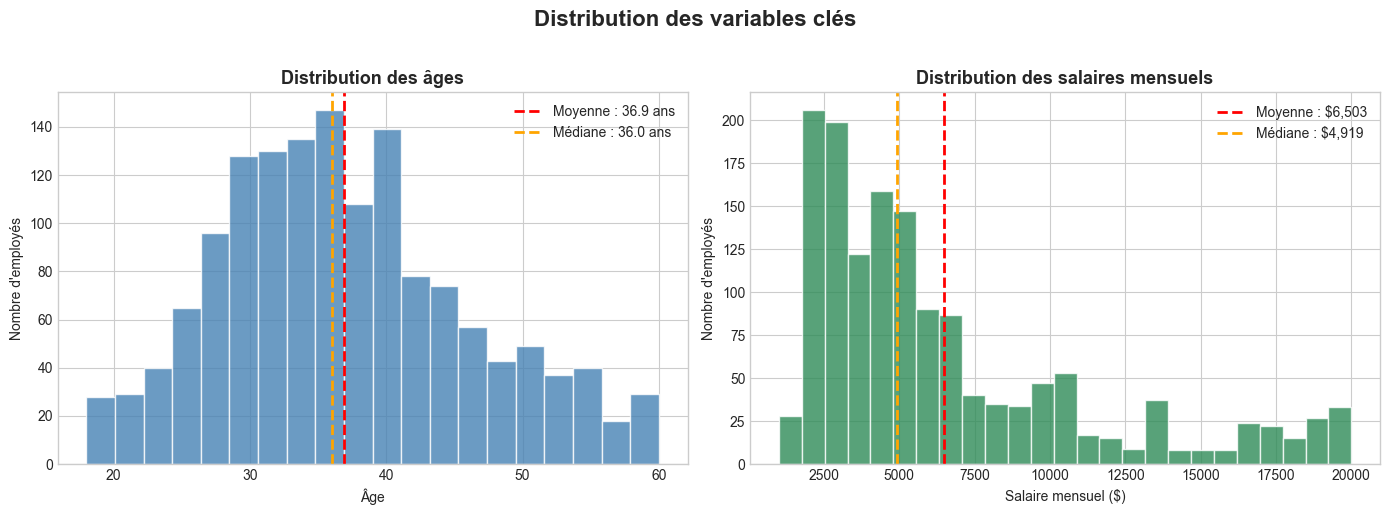

✅ Graphique sauvegardé : images/01_distributions.png


In [15]:
# ============================================================
# SECTION 5 — VISUALISATIONS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des variables clés', fontsize=16, fontweight='bold', y=1.02)

# --- Graphique 1 : Distribution des âges ---
axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f"Moyenne : {df['Age'].mean():.1f} ans")
axes[0].axvline(df['Age'].median(), color='orange', linestyle='--', linewidth=2, label=f"Médiane : {df['Age'].median():.1f} ans")
axes[0].set_title('Distribution des âges', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Âge')
axes[0].set_ylabel('Nombre d\'employés')
axes[0].legend()

# --- Graphique 2 : Distribution des salaires ---
axes[1].hist(df['MonthlyIncome'], bins=25, color='seagreen', edgecolor='white', alpha=0.8)
axes[1].axvline(df['MonthlyIncome'].mean(), color='red', linestyle='--', linewidth=2, label=f"Moyenne : ${df['MonthlyIncome'].mean():,.0f}")
axes[1].axvline(df['MonthlyIncome'].median(), color='orange', linestyle='--', linewidth=2, label=f"Médiane : ${df['MonthlyIncome'].median():,.0f}")
axes[1].set_title('Distribution des salaires mensuels', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Salaire mensuel ($)')
axes[1].set_ylabel('Nombre d\'employés')
axes[1].legend()

plt.tight_layout()
plt.savefig('../../images/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : images/01_distributions.png")

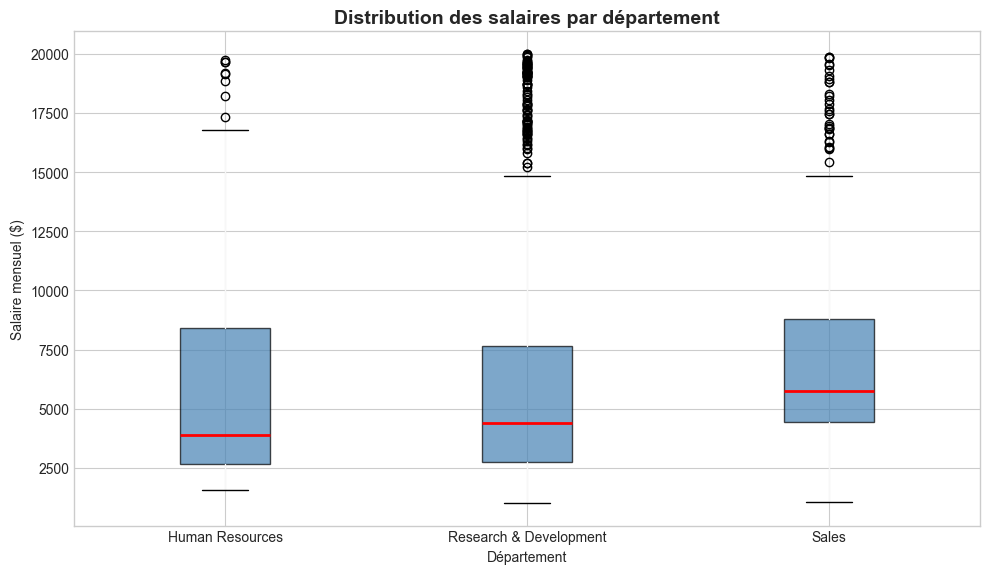

✅ Graphique sauvegardé : images/02_salaire_departement.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

# Boxplot salaire par département
df.boxplot(
    column='MonthlyIncome',
    by='Department',
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.7),
    medianprops=dict(color='red', linewidth=2)
)

ax.set_title('Distribution des salaires par département', fontsize=14, fontweight='bold')
ax.set_xlabel('Département')
ax.set_ylabel('Salaire mensuel ($)')
plt.suptitle('')  # Enlève le titre automatique de pandas
plt.tight_layout()
plt.savefig('../../images/02_salaire_departement.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : images/02_salaire_departement.png")

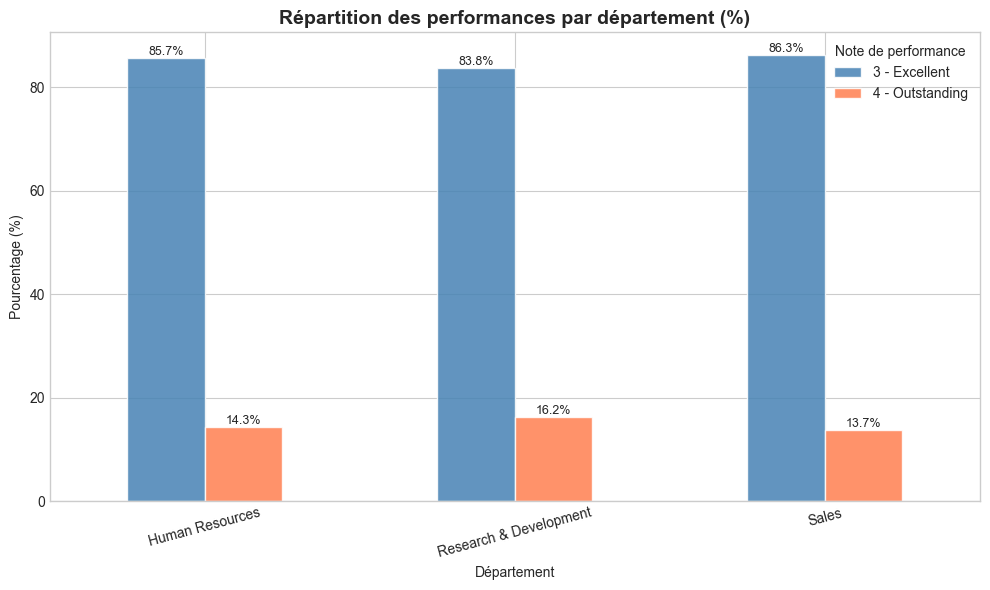

✅ Graphique sauvegardé : images/03_performance_departement.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

# Moyenne de performance par département
perf_dept = df.groupby('Department')['PerformanceRating'].value_counts(normalize=True).unstack() * 100

perf_dept.plot(
    kind='bar',
    ax=ax,
    color=['steelblue', 'coral'],
    edgecolor='white',
    alpha=0.85
)

ax.set_title('Répartition des performances par département (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Département')
ax.set_ylabel('Pourcentage (%)')
ax.legend(title='Note de performance', labels=['3 - Excellent', '4 - Outstanding'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)

# Ajouter les valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.savefig('../../images/03_performance_departement.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : images/03_performance_departement.png")

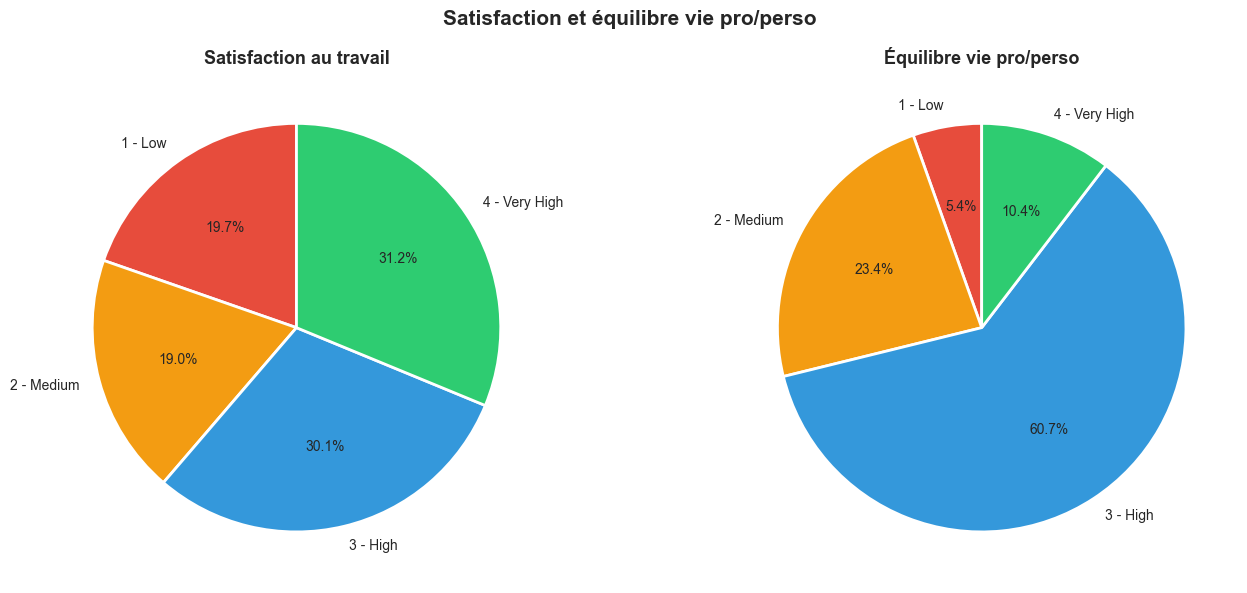

✅ Graphique sauvegardé : images/04_satisfaction.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Satisfaction et équilibre vie pro/perso', fontsize=15, fontweight='bold')

labels_satisfaction = ['1 - Low', '2 - Medium', '3 - High', '4 - Very High']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

# --- Pie chart 1 : Job Satisfaction ---
satisfaction_counts = df['JobSatisfaction'].value_counts().sort_index()
axes[0].pie(
    satisfaction_counts.values,
    labels=labels_satisfaction[:len(satisfaction_counts)],
    colors=colors[:len(satisfaction_counts)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title('Satisfaction au travail', fontsize=13, fontweight='bold')

# --- Pie chart 2 : Work-Life Balance ---
wlb_counts = df['WorkLifeBalance'].value_counts().sort_index()
axes[1].pie(
    wlb_counts.values,
    labels=labels_satisfaction[:len(wlb_counts)],
    colors=colors[:len(wlb_counts)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Équilibre vie pro/perso', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../../images/04_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : images/04_satisfaction.png")

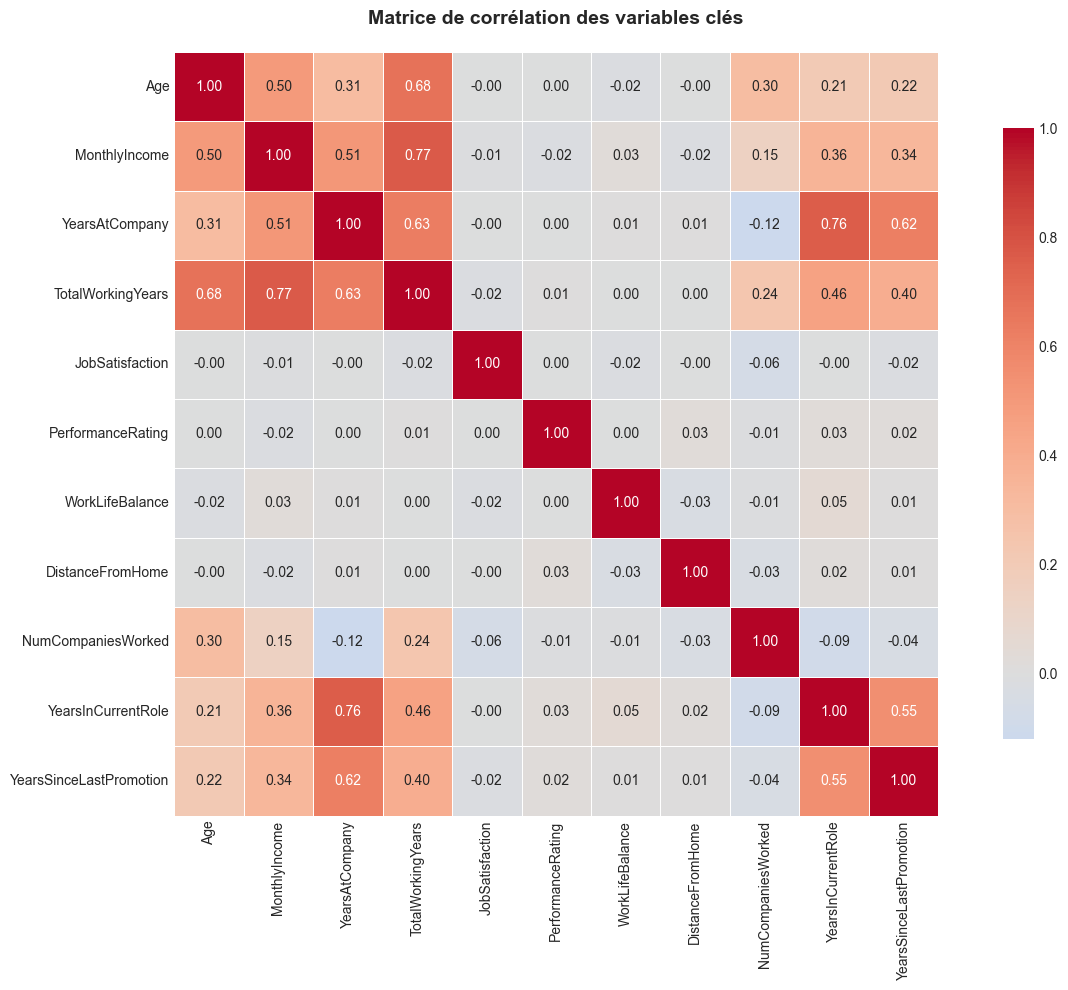

✅ Graphique sauvegardé : images/05_correlation.png


In [19]:
fig, ax = plt.subplots(figsize=(14, 10))

# Sélection des variables numériques pertinentes
vars_corr = [
    'Age', 'MonthlyIncome', 'YearsAtCompany',
    'TotalWorkingYears', 'JobSatisfaction',
    'PerformanceRating', 'WorkLifeBalance',
    'DistanceFromHome', 'NumCompaniesWorked',
    'YearsInCurrentRole', 'YearsSinceLastPromotion'
]

corr_matrix = df[vars_corr].corr().round(2)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Matrice de corrélation des variables clés', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../../images/05_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : images/05_correlation.png")

## 🎯 Section 6 — Détection des outliers

**Méthode utilisée : Règle des 1.5 × IQR**

Un outlier est une valeur anormalement éloignée des autres.
La règle IQR (Interquartile Range) définit :
- Borne inférieure = Q1 - 1.5 × IQR
- Borne supérieure = Q3 + 1.5 × IQR

Toute valeur en dehors de ces bornes est un outlier.

In [20]:
# ============================================================
# SECTION 6 — DÉTECTION DES OUTLIERS
# ============================================================

def detecter_outliers_iqr(df, colonne):
    """
    Détecte les outliers d'une colonne avec la règle 1.5 × IQR.
    
    Paramètres :
        df      : DataFrame pandas
        colonne : nom de la colonne à analyser
    
    Retourne :
        dict avec les statistiques et les outliers
    """
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1
    
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    outliers = df[(df[colonne] < borne_inf) | (df[colonne] > borne_sup)]
    
    return {
        'colonne': colonne,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'borne_inf': round(borne_inf, 2),
        'borne_sup': round(borne_sup, 2),
        'nb_outliers': len(outliers),
        'pct_outliers': round(len(outliers) / len(df) * 100, 2),
        'outliers': outliers
    }

print("✅ Fonction detecter_outliers_iqr() définie avec succès !")
print("\n💡 Explication de la règle IQR :")
print("   IQR = Q3 - Q1 (l'écart entre le 75ème et 25ème percentile)")
print("   Borne inférieure = Q1 - 1.5 × IQR")
print("   Borne supérieure = Q3 + 1.5 × IQR")
print("   Tout ce qui dépasse ces bornes = OUTLIER")

✅ Fonction detecter_outliers_iqr() définie avec succès !

💡 Explication de la règle IQR :
   IQR = Q3 - Q1 (l'écart entre le 75ème et 25ème percentile)
   Borne inférieure = Q1 - 1.5 × IQR
   Borne supérieure = Q3 + 1.5 × IQR
   Tout ce qui dépasse ces bornes = OUTLIER


In [21]:
# Variables à analyser pour les outliers
variables_outliers = [
    'MonthlyIncome',
    'Age',
    'YearsAtCompany',
    'TotalWorkingYears',
    'DistanceFromHome',
    'NumCompaniesWorked',
    'YearsSinceLastPromotion'
]

print("=== RAPPORT DES OUTLIERS PAR VARIABLE ===\n")
print(f"{'Variable':<25} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'B.Inf':>8} {'B.Sup':>8} {'Outliers':>10} {'%':>6}")
print("-" * 90)

resultats_outliers = {}

for var in variables_outliers:
    res = detecter_outliers_iqr(df, var)
    resultats_outliers[var] = res
    print(
        f"{var:<25} "
        f"{res['Q1']:>8.1f} "
        f"{res['Q3']:>8.1f} "
        f"{res['IQR']:>8.1f} "
        f"{res['borne_inf']:>8.1f} "
        f"{res['borne_sup']:>8.1f} "
        f"{res['nb_outliers']:>10} "
        f"{res['pct_outliers']:>6.1f}%"
    )

=== RAPPORT DES OUTLIERS PAR VARIABLE ===

Variable                        Q1       Q3      IQR    B.Inf    B.Sup   Outliers      %
------------------------------------------------------------------------------------------
MonthlyIncome               2911.0   8379.0   5468.0  -5291.0  16581.0        114    7.8%
Age                           30.0     43.0     13.0     10.5     62.5          0    0.0%
YearsAtCompany                 3.0      9.0      6.0     -6.0     18.0        104    7.1%
TotalWorkingYears              6.0     15.0      9.0     -7.5     28.5         63    4.3%
DistanceFromHome               2.0     14.0     12.0    -16.0     32.0          0    0.0%
NumCompaniesWorked             1.0      4.0      3.0     -3.5      8.5         52    3.5%
YearsSinceLastPromotion        0.0      3.0      3.0     -4.5      7.5        107    7.3%


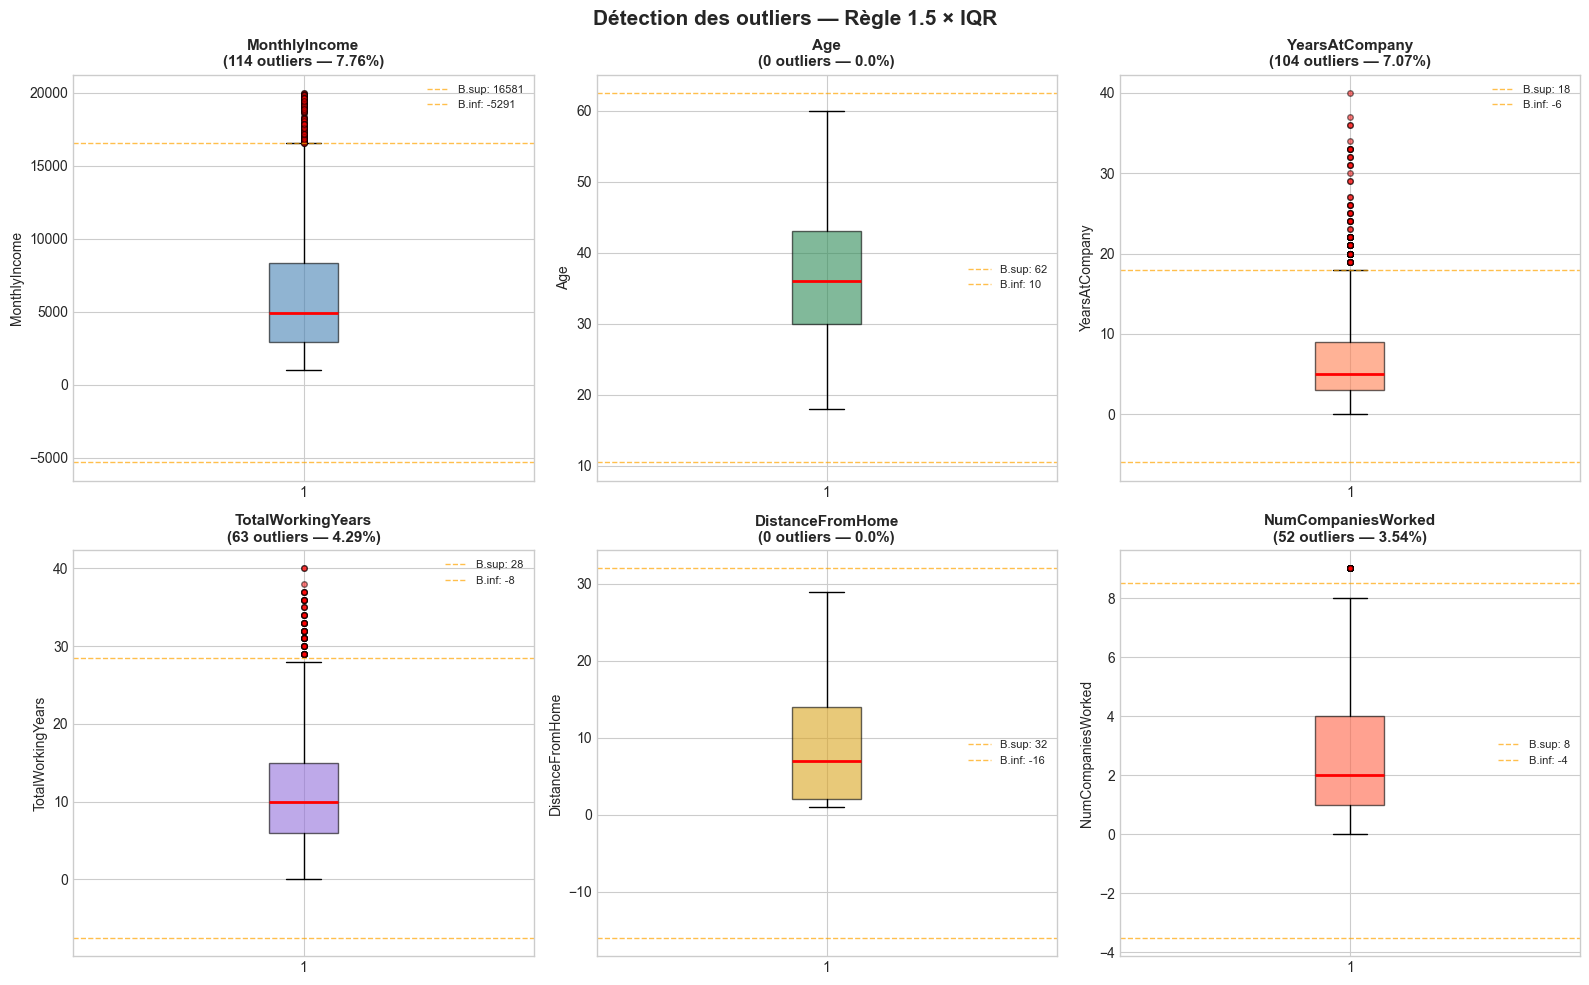

✅ Graphique sauvegardé : images/06_outliers_boxplots.png


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Détection des outliers — Règle 1.5 × IQR', fontsize=15, fontweight='bold')

vars_plot = [
    'MonthlyIncome', 'Age', 'YearsAtCompany',
    'TotalWorkingYears', 'DistanceFromHome', 'NumCompaniesWorked'
]

colors_box = ['steelblue', 'seagreen', 'coral', 'mediumpurple', 'goldenrod', 'tomato']

for i, (var, color) in enumerate(zip(vars_plot, colors_box)):
    row, col = i // 3, i % 3
    ax = axes[row][col]
    
    res = resultats_outliers[var]
    
    # Boxplot
    bp = ax.boxplot(
        df[var].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='red',
                       markersize=4, alpha=0.5)
    )
    
    ax.set_title(
        f'{var}\n({res["nb_outliers"]} outliers — {res["pct_outliers"]}%)',
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel(var)
    
    # Annotation des bornes
    ax.axhline(res['borne_sup'], color='orange', linestyle='--',
               linewidth=1, alpha=0.7, label=f'B.sup: {res["borne_sup"]:.0f}')
    ax.axhline(res['borne_inf'], color='orange', linestyle='--',
               linewidth=1, alpha=0.7, label=f'B.inf: {res["borne_inf"]:.0f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../../images/06_outliers_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : images/06_outliers_boxplots.png")

In [23]:
# Focus sur les outliers de salaire (les plus importants business)
print("=== FOCUS : OUTLIERS DE SALAIRE (MonthlyIncome) ===\n")

res_salaire = resultats_outliers['MonthlyIncome']
outliers_salaire = res_salaire['outliers']

print(f"Borne supérieure : ${res_salaire['borne_sup']:,.0f}")
print(f"Nombre d'outliers : {res_salaire['nb_outliers']} employés ({res_salaire['pct_outliers']}%)")
print(f"\nCes employés gagnent plus de ${res_salaire['borne_sup']:,.0f}/mois\n")

# Profil des outliers salariaux
print("Profil des hauts salaires (outliers) :")
profil = outliers_salaire[['JobRole', 'Department', 'MonthlyIncome',
                            'YearsAtCompany', 'PerformanceRating']].sort_values(
    'MonthlyIncome', ascending=False
).head(10)

print(profil.to_string(index=False))

print(f"\n💡 Salaire moyen des outliers : ${outliers_salaire['MonthlyIncome'].mean():,.0f}")
print(f"   Salaire max : ${outliers_salaire['MonthlyIncome'].max():,.0f}")
print(f"   Poste dominant : {outliers_salaire['JobRole'].mode()[0]}")

=== FOCUS : OUTLIERS DE SALAIRE (MonthlyIncome) ===

Borne supérieure : $16,581
Nombre d'outliers : 114 employés (7.76%)

Ces employés gagnent plus de $16,581/mois

Profil des hauts salaires (outliers) :
          JobRole             Department  MonthlyIncome  YearsAtCompany  PerformanceRating
          Manager Research & Development          19999              33                  3
Research Director Research & Development          19973              21                  4
          Manager Research & Development          19943               5                  3
          Manager Research & Development          19926               5                  3
          Manager Research & Development          19859               5                  3
          Manager                  Sales          19847              29                  4
          Manager                  Sales          19845              32                  3
          Manager                  Sales          19833             

## 💡 Section 7 — Insights et recommandations

Synthèse des principaux enseignements de cette analyse.

In [24]:
# ============================================================
# SECTION 7 — INSIGHTS ET RECOMMANDATIONS
# ============================================================

print("=" * 60)
print("   SYNTHÈSE DES INSIGHTS BUSINESS")
print("=" * 60)

print(f"""
📊 PROFIL GÉNÉRAL DE L'ENTREPRISE
   • Effectif analysé     : {len(df):,} employés
   • Âge moyen           : {df['Age'].mean():.1f} ans
   • Salaire moyen       : ${df['MonthlyIncome'].mean():,.0f}/mois
   • Ancienneté moyenne  : {df['YearsAtCompany'].mean():.1f} ans

📈 PERFORMANCES
   • {(df['PerformanceRating'] == 4).sum()} employés Outstanding ({(df['PerformanceRating'] == 4).mean()*100:.1f}%)
   • {(df['PerformanceRating'] == 3).sum()} employés Excellent ({(df['PerformanceRating'] == 3).mean()*100:.1f}%)
   • ⚠️  Aucun employé noté 1 ou 2 → biais d'évaluation possible

😊 SATISFACTION
   • Satisfaction élevée (3-4) : {(df['JobSatisfaction'] >= 3).mean()*100:.1f}% des employés
   • Équilibre vie pro/perso bon (3-4) : {(df['WorkLifeBalance'] >= 3).mean()*100:.1f}%

💰 SALAIRES
   • Département le mieux payé : {df.groupby('Department')['MonthlyIncome'].mean().idxmax()}
     (${df.groupby('Department')['MonthlyIncome'].mean().max():,.0f}/mois en moyenne)
   • Outliers salariaux : {resultats_outliers['MonthlyIncome']['nb_outliers']} employés
     (>${resultats_outliers['MonthlyIncome']['borne_sup']:,.0f}/mois)

🎯 RECOMMANDATIONS
   1. Investiguer le biais d'évaluation (0% de notes 1-2)
   2. Analyser pourquoi {(df['WorkLifeBalance'] == 1).sum()} employés ont un mauvais équilibre pro/perso
   3. Examiner les écarts de salaire entre départements
   4. Étudier le profil des hauts salaires (outliers) pour la rétention
""")

print("✅ Analyse complète terminée !")

   SYNTHÈSE DES INSIGHTS BUSINESS

📊 PROFIL GÉNÉRAL DE L'ENTREPRISE
   • Effectif analysé     : 1,470 employés
   • Âge moyen           : 36.9 ans
   • Salaire moyen       : $6,503/mois
   • Ancienneté moyenne  : 7.0 ans

📈 PERFORMANCES
   • 226 employés Outstanding (15.4%)
   • 1244 employés Excellent (84.6%)
   • ⚠️  Aucun employé noté 1 ou 2 → biais d'évaluation possible

😊 SATISFACTION
   • Satisfaction élevée (3-4) : 61.3% des employés
   • Équilibre vie pro/perso bon (3-4) : 71.2%

💰 SALAIRES
   • Département le mieux payé : Sales
     ($6,959/mois en moyenne)
   • Outliers salariaux : 114 employés
     (>$16,581/mois)

🎯 RECOMMANDATIONS
   1. Investiguer le biais d'évaluation (0% de notes 1-2)
   2. Analyser pourquoi 80 employés ont un mauvais équilibre pro/perso
   3. Examiner les écarts de salaire entre départements
   4. Étudier le profil des hauts salaires (outliers) pour la rétention

✅ Analyse complète terminée !


In [25]:
# Récapitulatif des fichiers générés
print("=" * 50)
print("   FICHIERS GÉNÉRÉS PAR CE NOTEBOOK")
print("=" * 50)
print("""
📓 Notebook :
   notebooks/python/02_hr_analytics_python.ipynb

🖼️ Images sauvegardées dans images/ :
   01_distributions.png
   02_salaire_departement.png
   03_performance_departement.png
   04_satisfaction.png
   05_correlation.png
   06_outliers_boxplots.png

📊 Dataset source :
   dataset/hr_analytics.csv
""")
print("✅ Projet 2 Python — TERMINÉ !")

   FICHIERS GÉNÉRÉS PAR CE NOTEBOOK

📓 Notebook :
   notebooks/python/02_hr_analytics_python.ipynb

🖼️ Images sauvegardées dans images/ :
   01_distributions.png
   02_salaire_departement.png
   03_performance_departement.png
   04_satisfaction.png
   05_correlation.png
   06_outliers_boxplots.png

📊 Dataset source :
   dataset/hr_analytics.csv

✅ Projet 2 Python — TERMINÉ !
